In [2]:
import pandas as pd
import numpy as np

# fetching the data from downloaded abalone txt
file_path = "abalone_data.txt"
column_names = [
    "Sex", "Length", "Diameter", "Height", "Whole_weight",
    "Shucked_weight", "Viscera_weight", "Shell_weight", "Rings"
]
df = pd.read_csv(file_path, names=column_names)

# creating the Age variable (defined from UCI)
df['Age'] = df['Rings'] + 1.5

# Market Value Proxy
diam_75 = df['Diameter'].quantile(0.75)
weight_75 = df['Whole_weight'].quantile(0.75)
diam_25 = df['Diameter'].quantile(0.25)
weight_25 = df['Whole_weight'].quantile(0.25)

# logical conditions for each market tier
conditions = [
    (df['Diameter'] >= diam_75) & (df['Whole_weight'] >= weight_75), # premium
    (df['Diameter'] >= diam_25) & (df['Whole_weight'] >= weight_25)  # standard
]

# assigning base prices for premium, standard, and sub-standard
base_prices = [50.0, 30.0, 15.0]

# applying the conditions to create a base price column
df['Base_Price'] = np.select(conditions, base_prices[:-1], default=base_prices[-1])

# noise: epsilon ~ N(0, sigma^2)
# using a standard deviation of 3 to represent realistic price fluctuation
np.random.seed(42)
noise = np.random.normal(loc=0.0, scale=3.0, size=len(df))

# calculating final market value, rounding it, and clipping at 0 to prevent negative prices
df['Market_Value'] = np.round(df['Base_Price'] + noise, 2)
df['Market_Value'] = df['Market_Value'].clip(lower=0)

# dropping the intermediate base price column to keep the dataframe clean
df.drop(columns=['Base_Price'], inplace=True)

# organizing and separating the data for specific modeling tasks
targets = df[['Age', 'Market_Value']]
pca_features = df[['Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight']]
remaining_predictors = df[['Sex', 'Length', 'Diameter', 'Height']]

# Verify the output
print("Data preview:")
print(df[['Diameter', 'Whole_weight', 'Age', 'Market_Value']].head())

Data preview:
   Diameter  Whole_weight   Age  Market_Value
0     0.365        0.5140  16.5         31.49
1     0.265        0.2255   8.5         14.59
2     0.420        0.6770  10.5         31.94
3     0.365        0.5160  11.5         34.57
4     0.255        0.2050   8.5         14.30


Loaded shape: (4177, 15)
  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  Rings   Age  Market_Value  log_Whole_weight  \
0         0.150     15  16.5         31.49         -0.665530   
1         0.070      7   8.5         14.59         -1.489431   
2         0.210      9  10.5         31.94         -0.390083   
3         0.155     10  11.5         34.57         -0.661647   
4         0.055      7   8.5         14.30         -1.584740   

   log_Shucked_weight  log_Viscera_weight  log_Shell_weight  
0           -1.493875           -2.292625

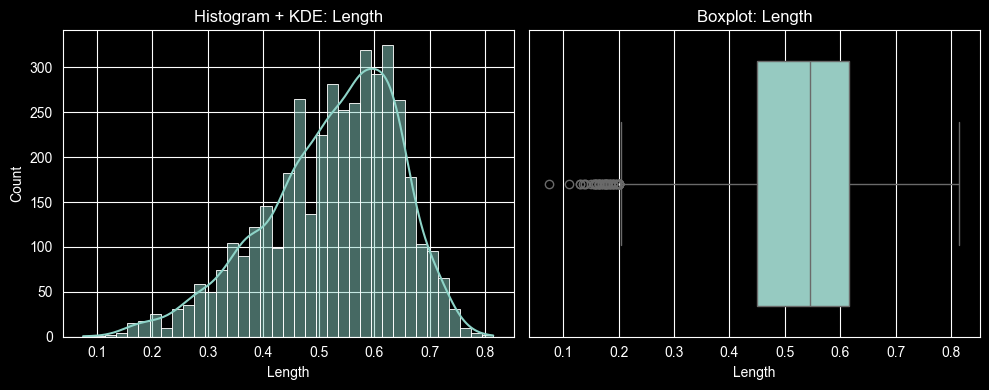


--- Diameter ---
Mean: 0.4079
Median: 0.4250
Std: 0.0992
Skewness: -0.6090
Outliers (IQR method): 59


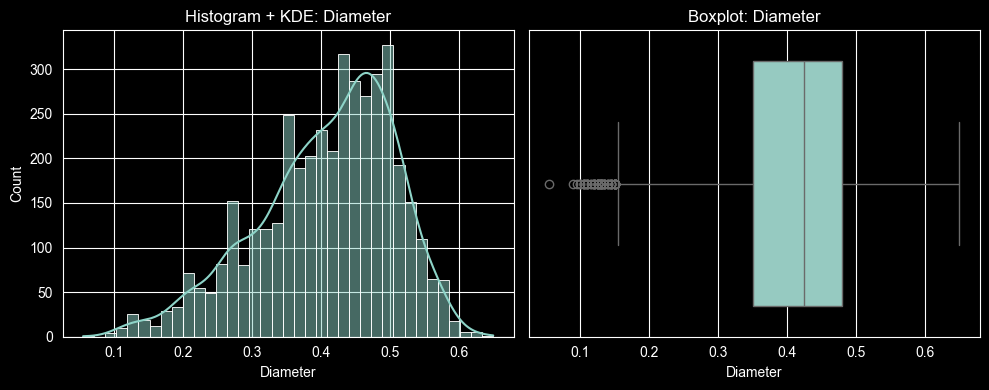


--- Height ---
Mean: 0.1395
Median: 0.1400
Std: 0.0418
Skewness: 3.1277
Outliers (IQR method): 29


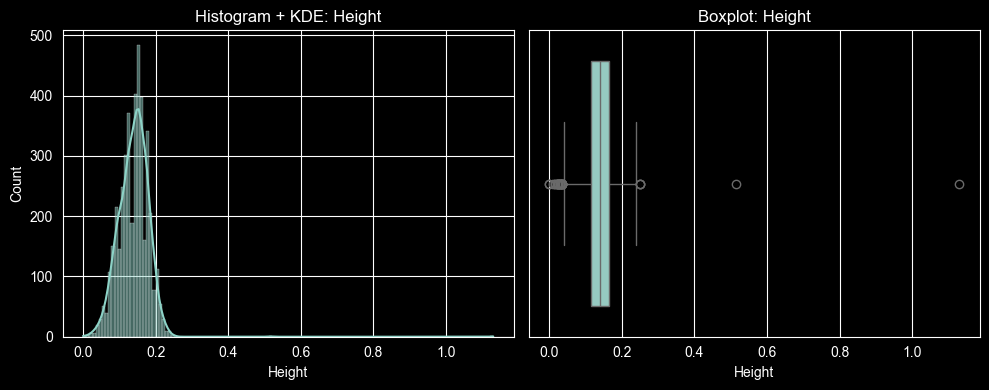


--- Whole_weight ---
Mean: 0.8287
Median: 0.7995
Std: 0.4904
Skewness: 0.5308
Outliers (IQR method): 30


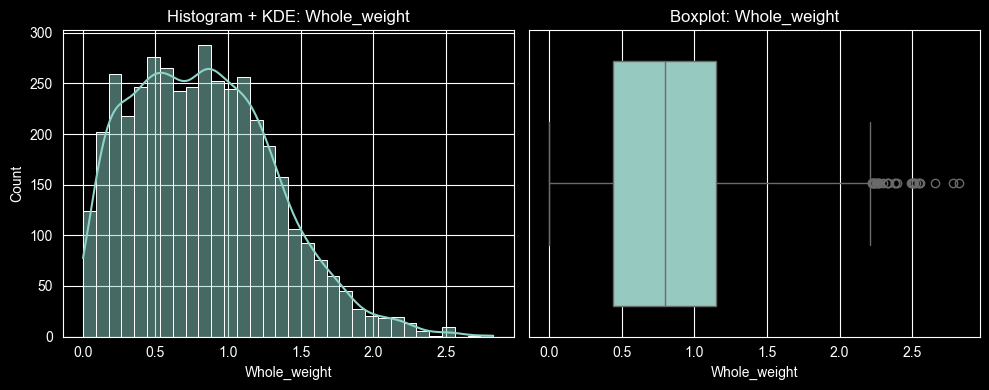


--- Shucked_weight ---
Mean: 0.3594
Median: 0.3360
Std: 0.2220
Skewness: 0.7188
Outliers (IQR method): 48


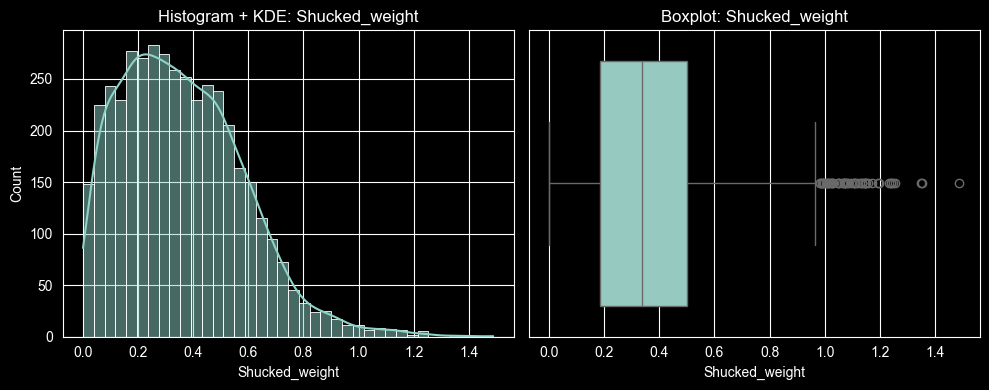


--- Viscera_weight ---
Mean: 0.1806
Median: 0.1710
Std: 0.1096
Skewness: 0.5916
Outliers (IQR method): 26


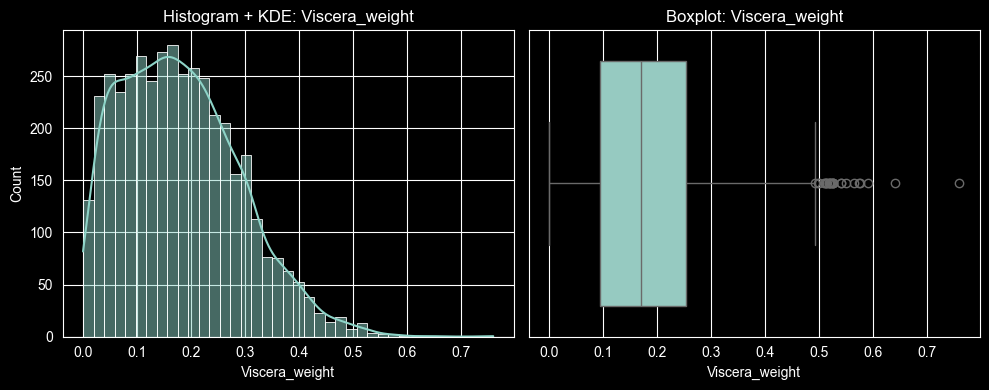


--- Shell_weight ---
Mean: 0.2388
Median: 0.2340
Std: 0.1392
Skewness: 0.6207
Outliers (IQR method): 35


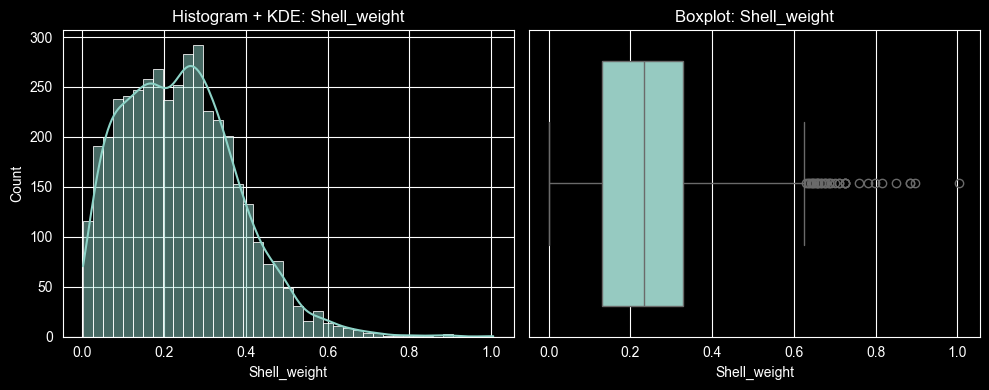


--- Rings ---
Mean: 9.9337
Median: 9.0000
Std: 3.2242
Skewness: 1.1137
Outliers (IQR method): 278


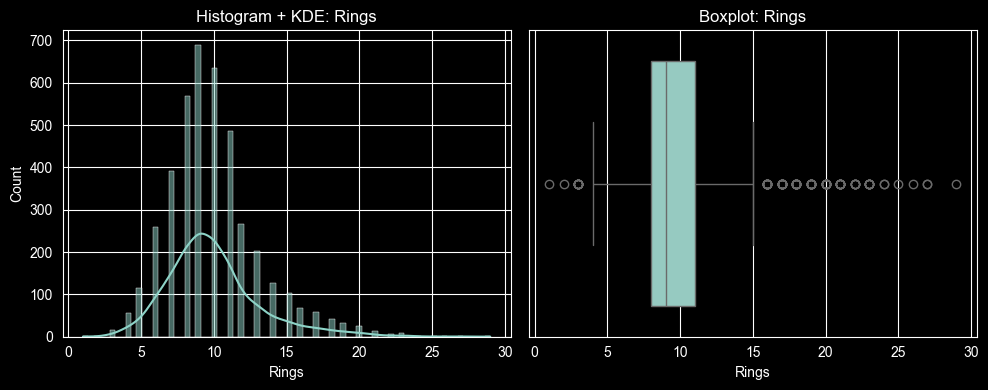


--- Age ---
Mean: 11.4337
Median: 10.5000
Std: 3.2242
Skewness: 1.1137
Outliers (IQR method): 278


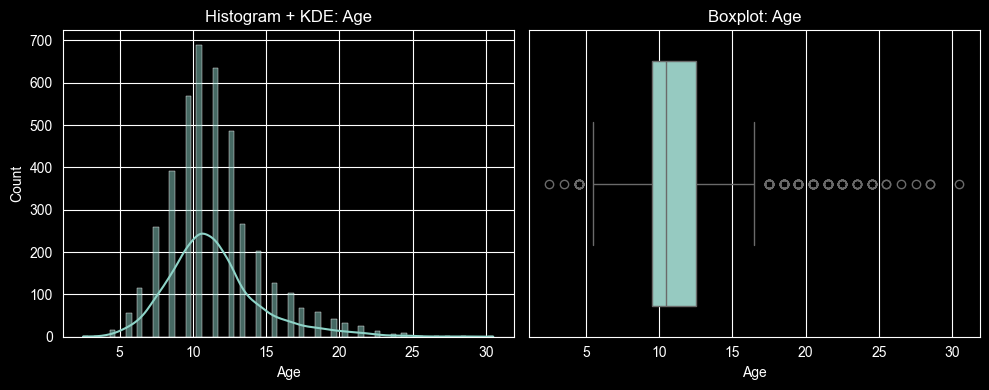


--- Market_Value ---
Mean: 30.5361
Median: 29.7500
Std: 12.5788
Skewness: 0.3500
Outliers (IQR method): 9


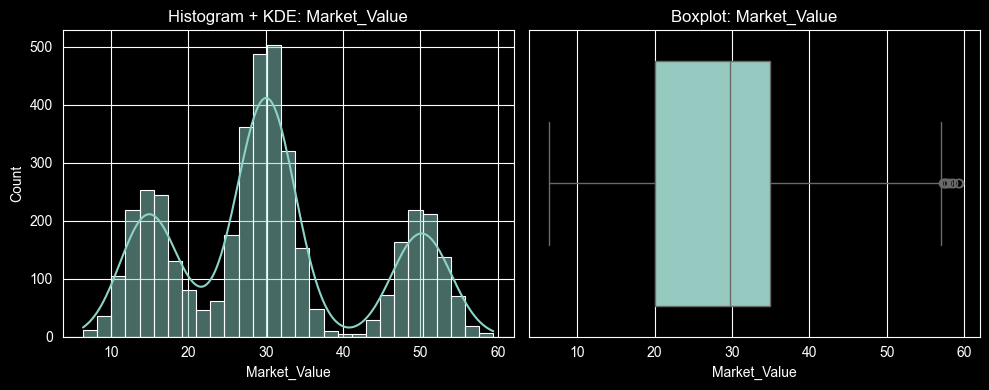


--- log_Whole_weight ---
Mean: -0.4403
Median: -0.2238
Std: 0.8360
Skewness: -1.4231
Outliers (IQR method): 160


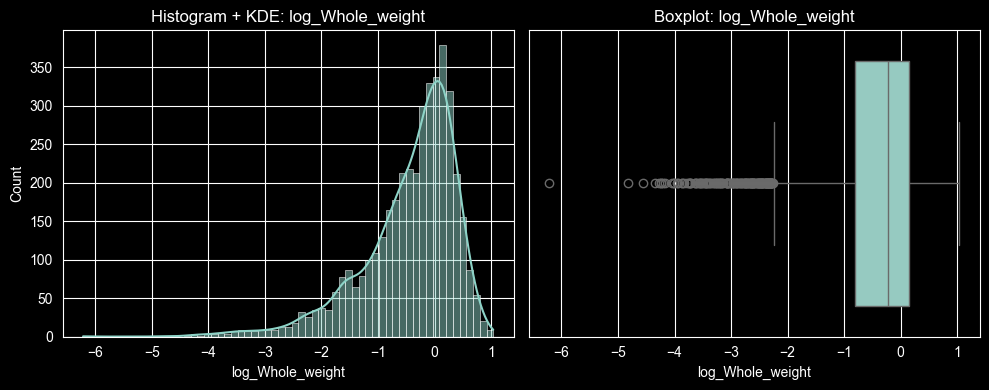


--- log_Shucked_weight ---
Mean: -1.2909
Median: -1.0906
Std: 0.8609
Skewness: -1.4107
Outliers (IQR method): 160


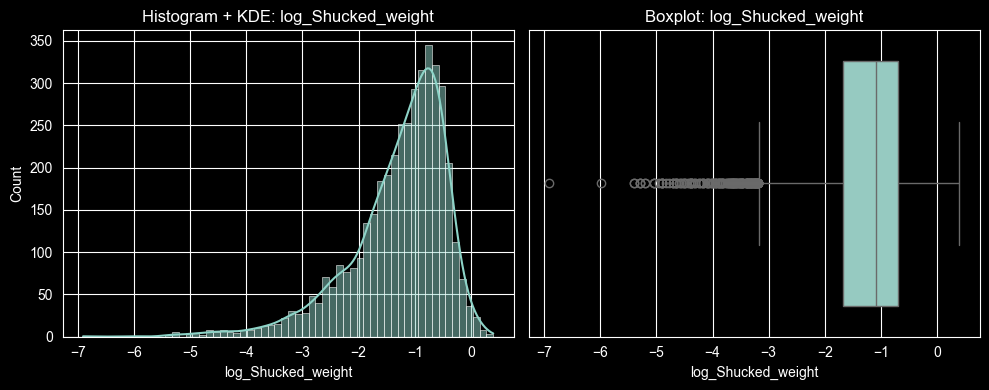


--- log_Viscera_weight ---
Mean: -1.9733
Median: -1.7661
Std: 0.8497
Skewness: -1.3960
Outliers (IQR method): 150


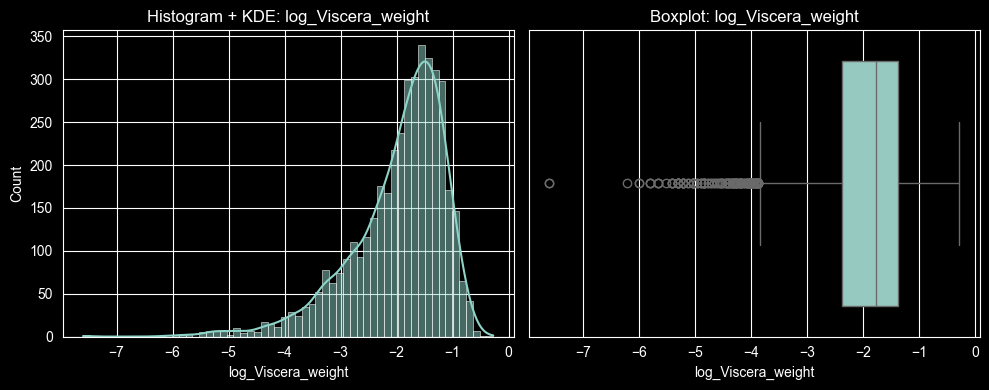


--- log_Shell_weight ---
Mean: -1.6718
Median: -1.4524
Std: 0.8115
Skewness: -1.4347
Outliers (IQR method): 166


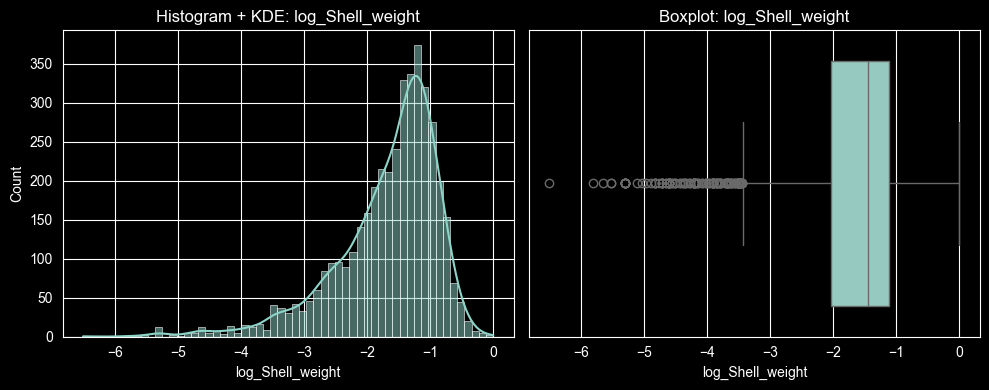

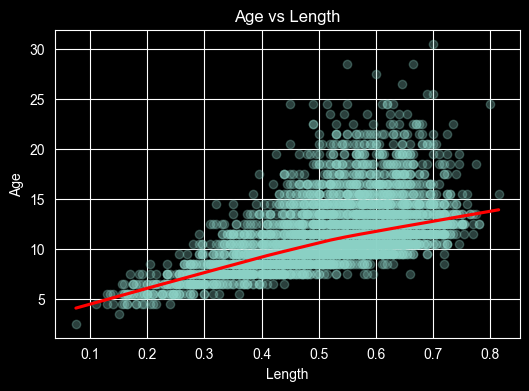

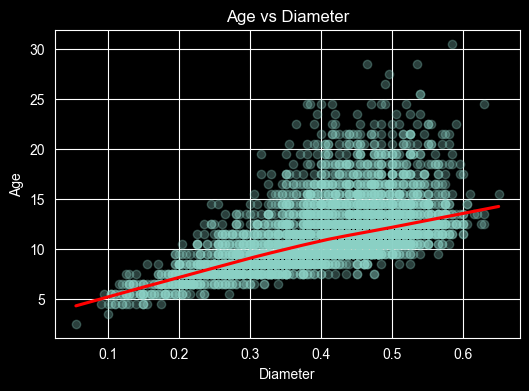

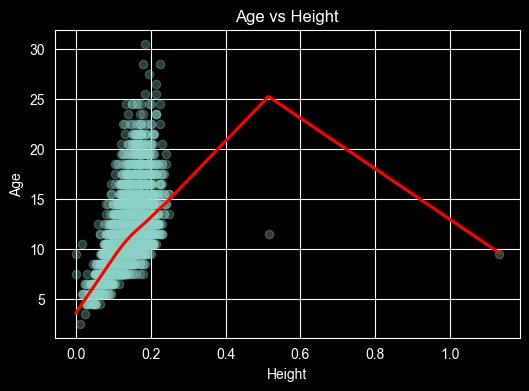

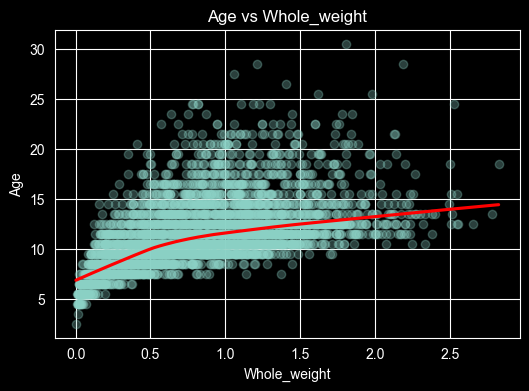

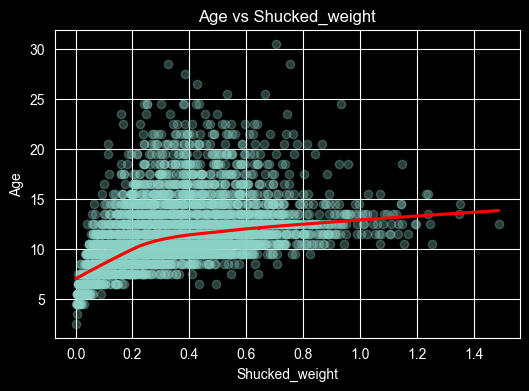

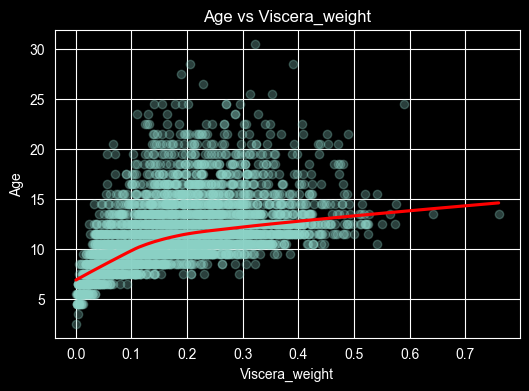

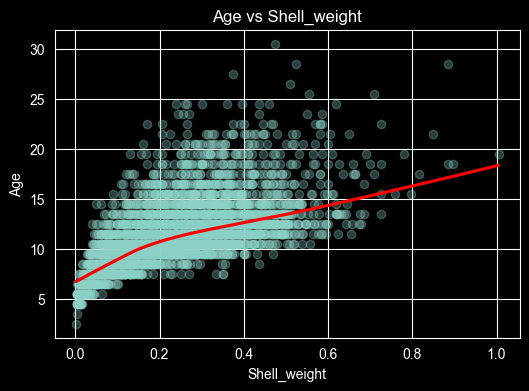

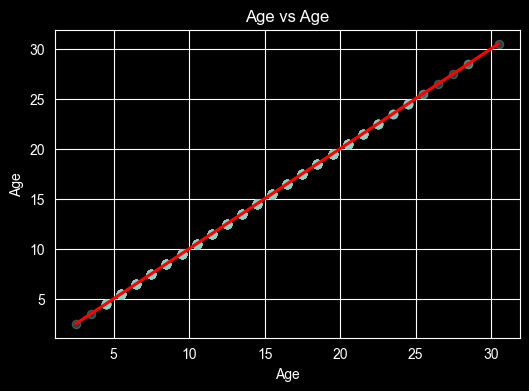

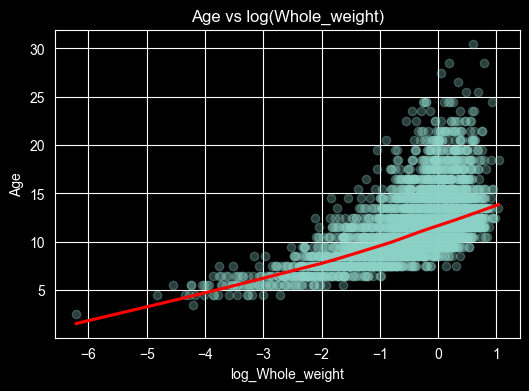

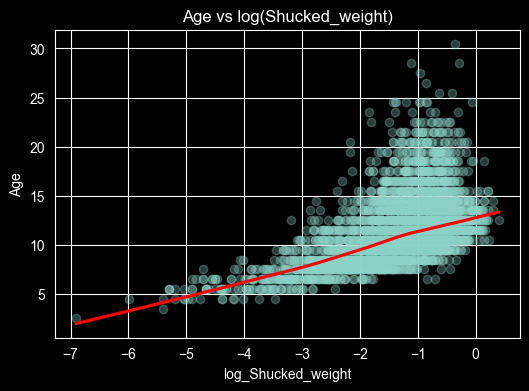

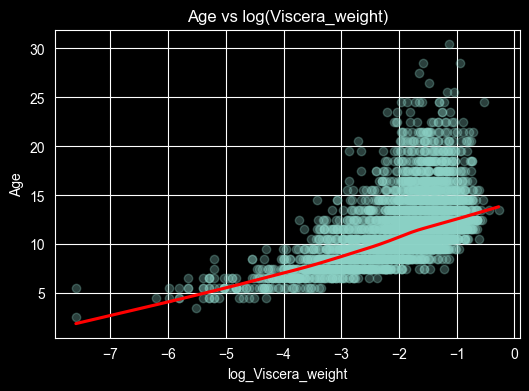

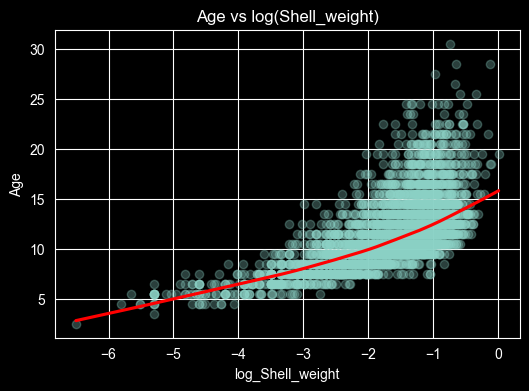

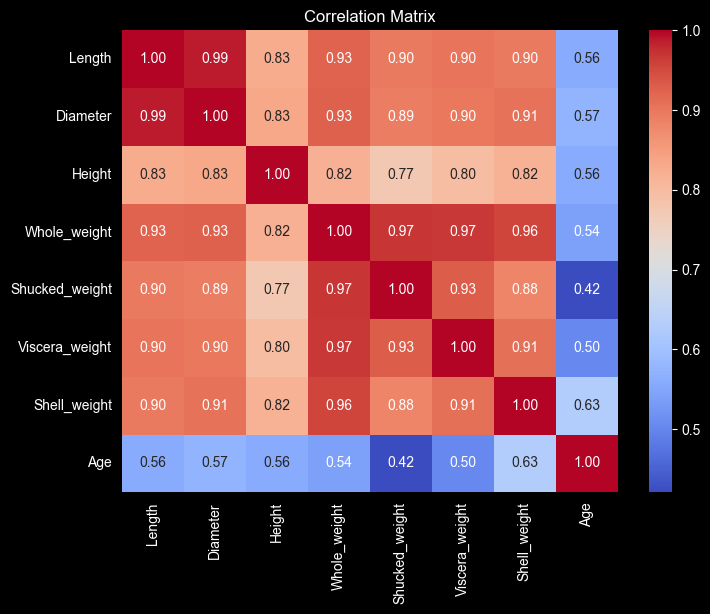

          Feature         VIF
0           const   65.605491
1          Length   40.779070
2        Diameter   42.203488
3          Height    3.609767
4    Whole_weight  113.780726
5  Shucked_weight   32.452813
6  Viscera_weight   17.582701
7    Shell_weight   21.548538
8             Age    2.116984


In [4]:
"""
Abalone Dataset Exploratory Data Analysis
"""

import seaborn as sns
from scipy.stats import skew
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Loaded shape:", df.shape)
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    print(f"\n--- {col} ---")

    mean = df[col].mean()
    median = df[col].median()
    std = df[col].std()
    skewness = skew(df[col])

    print(f"Mean: {mean:.4f}")
    print(f"Median: {median:.4f}")
    print(f"Std: {std:.4f}")
    print(f"Skewness: {skewness:.4f}")

    #IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"Outliers (IQR method): {len(outliers)}")

    fig, axes = plt.subplots(1, 2, figsize=(10,4))

    # Histogram + KDE
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram + KDE: {col}")

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot: {col}")

    plt.tight_layout()
    plt.show()

predictors = [
    "Length", "Diameter", "Height",
    "Whole_weight", "Shucked_weight",
    "Viscera_weight", "Shell_weight", "Age"
]

for col in predictors:
    plt.figure(figsize=(6, 4))
    sns.regplot(
        x=df[col],
        y=df["Age"],
        lowess=True,
        scatter_kws={"alpha": 0.3},
        line_kws={"color": "red"}
    )
    plt.title(f"Age vs {col}")
    plt.show()

for col in ["Whole_weight", "Shucked_weight",
            "Viscera_weight", "Shell_weight"]:
    df[f"log_{col}"] = np.log(df[col] + 1e-6)

    plt.figure(figsize=(6, 4))
    sns.regplot(
        x=df[f"log_{col}"],
        y=df["Age"],
        lowess=True,
        scatter_kws={"alpha": 0.3},
        line_kws={"color": "red"}
    )
    plt.title(f"Age vs log({col})")
    plt.show()

predictors = [
    "Length", "Diameter", "Height",
    "Whole_weight", "Shucked_weight",
    "Viscera_weight", "Shell_weight", "Age"
]

corr = df[predictors].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

X = df[predictors]
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)